In [1]:
# basic notebook for plotting logos from annotated seqlets for highlighting specific examples #

In [1]:
# import packages
import pandas as pd
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as mpl
import matplotlib
import torch
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme

In [2]:
# define a function for reading in data and concatenating #
def read_in_sat_mut (path2satmut, chunksize):
    # define a list for concatenating #
    chunks2cat = []
    # iterate through chunked tsv #
    for chunk in tqdm(pd.read_csv(path2satmut, sep = '\t', chunksize=chunksize)):
        chunks2cat.append(chunk)
    # concatenate chunks #
    cat_df = pd.concat(chunks2cat)
    return cat_df

In [3]:
# load mpac preds
preds = read_in_sat_mut('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/mpac_preds/GRCh38-dELS-chr11-ALL-mpac-017.tsv.gz',
                        1000000)
# get mean preds
groupby_cols = [i for i in preds.keys() if 'k562' in i or 'hepg2' in i or 'sknsh' in i or 'id' in i]
mean_groupy = preds.filter(groupby_cols).groupby('id').mean()

0it [00:00, ?it/s]

58it [02:10,  2.25s/it]


In [4]:
# load plotLogo tensors
plotLogo_tensors = torch.load('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/chr11_plotLogo_tensors.pt')

In [15]:
# load annotated seqlets
annotated_seqlets = torch.load('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/annotated_seqlets/chr11_annotated_seqlets_0.01.pt',
                               weights_only=False)

In [6]:
annotated_seqlets['K562'][-1]

,example_idx,start,end,attribution,p-value,enhancer_id,pval
0,SMAD4_HUMAN.H11MO.0.B,105,115,-15.017390,-2.052558e-11,EH38E2968853,0.000671
1,NR6A1_HUMAN.H11MO.0.B,149,161,-13.408562,2.357590e-07,EH38E1537442,0.001178
2,GFI1B_HUMAN.H11MO.0.A,169,181,-13.264369,2.946931e-07,EH38E2990714,0.000315
3,RFX2_HUMAN.H11MO.0.A,138,148,-13.081866,4.140274e-07,EH38E2947791,0.000257
4,ELK1_HUMAN.H11MO.0.B,25,42,29.216593,4.403224e-07,EH38E2973803,0.000006
...,...,...,...,...,...,...,...
88340,FOSL1_HUMAN.H11MO.0.A,113,117,2.804480,9.985459e-03,EH38E1531922,0.000097
88341,ZN490_HUMAN.H11MO.0.C,147,151,2.812202,9.985459e-03,EH38E1561518,0.000174
88342,INSM1_HUMAN.H11MO.0.C,65,69,2.810187,9.985459e-03,EH38E1556581,0.000006
88343,INSM1_HUMAN.H11MO.0.C,191,195,2.816246,9.985459e-03,EH38E2939108,0.000148


In [16]:
# define a function where we take a random enhancer and plot the thresholds for each cell type
def plot_specific_logos (annotated_seqlets,
                         cell,
                         enhancerID,
                         plotLogo_tensors,
                         save):
    # define colors for each cell type for highlighting logos
    if cell == 'K562':
        highlight = '#00A79D'
    elif cell == 'HepG2':
        highlight = '#FBB040'
    elif cell == 'SKNSH':
        highlight = '#ED1C24'
    print(cell)
    # return index of chosen enhancer
    enh_idx = list(plotLogo_tensors['K562'].keys()).index(enhancerID)
    cell_seqlets = annotated_seqlets[cell][0]
    annotation_seqlets = annotated_seqlets[cell][-1]
    # filter for the random enhancer by enhancer index
    enh_seqlets = cell_seqlets[cell_seqlets['example_idx'] == enh_idx]
    enh_ann = annotation_seqlets.iloc[enh_seqlets.index]
    if len(enh_seqlets) > 0:
        mpl.figure(figsize=(20,3), dpi=300)
        ax = mpl.subplot(111)
        matplotlib.rcParams['pdf.fonttype'] = 42
        matplotlib.rcParams['ps.fonttype'] = 42
        plot_logo(plotLogo_tensors[cell][enhancerID], annotations=enh_ann, score_key='attribution')
        for idx, row in enh_seqlets.iterrows():
            start, stop = row[['start', 'end']].tolist()
            ax.axvspan(start - 0.5, stop + 0.5, alpha=0.25, color=highlight)
        #mpl.ylim(-.5, .5)
        mpl.title(f'tangermeme seqlets for {enhancerID}, threshold: 0.01 | {cell}')
        mpl.tight_layout()
        if save == True:
            mpl.savefig(f'{enhancerID}_sat_mut_logos.pdf')
    else:
        print('no seqlets for this enhancer at this threshold')
        mpl.figure(figsize=(20,1), dpi=300)
        plot_logo(plotLogo_tensors[cell][enhancerID])
        mpl.title(f'tangermeme seqlets for {enhancerID}, threshold: 0.01 | {cell}')
        mpl.show()

K562


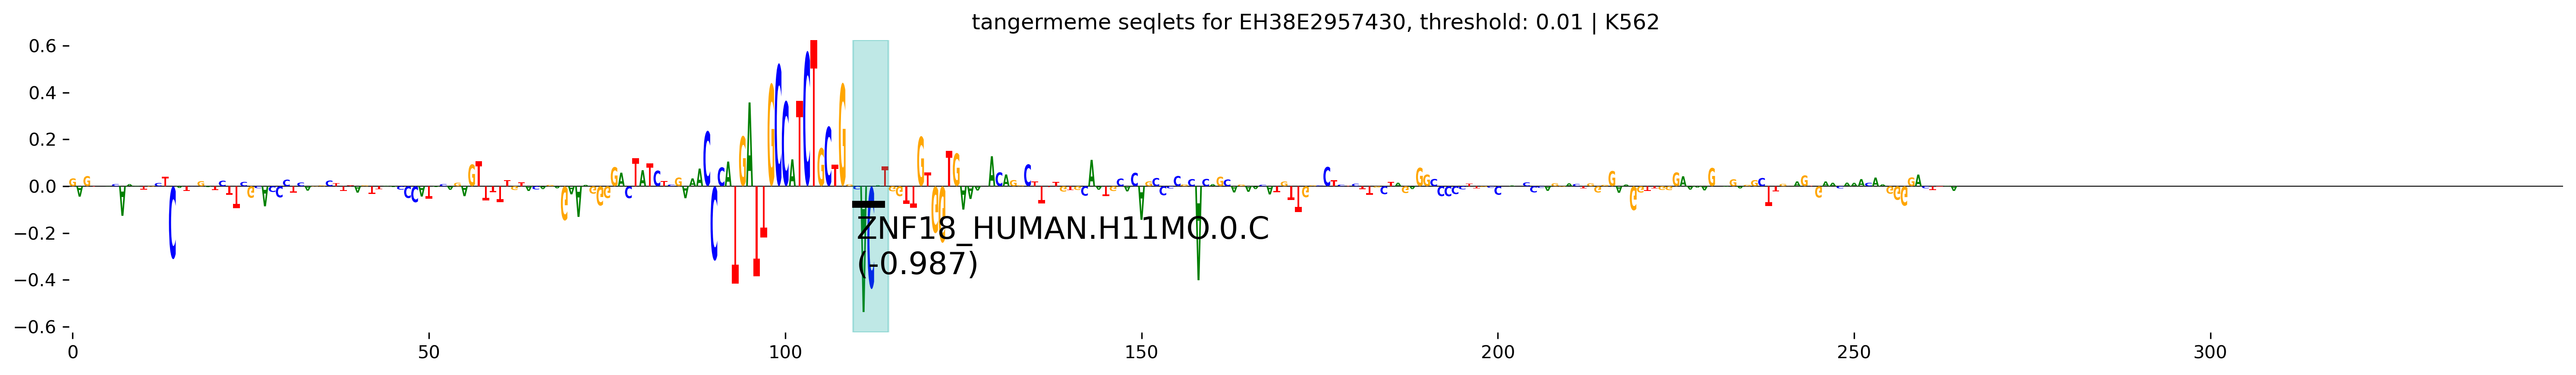

In [17]:
# EH38E2957430 - MYBPC3 distal enhancer, ~3.5kb away
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E2957430',
                    plotLogo_tensors,
                    True)

In [18]:
mean_groupy.loc['EH38E2957430',:]

k562_ref_pred      0.417027
k562_alt_pred      0.412448
k562_skew_pred    -0.004579
hepg2_ref_pred     0.508532
hepg2_alt_pred     0.503212
hepg2_skew_pred   -0.005320
sknsh_ref_pred     0.152435
sknsh_alt_pred     0.160375
sknsh_skew_pred    0.007940
Name: EH38E2957430, dtype: float64

K562
no seqlets for this enhancer at this threshold


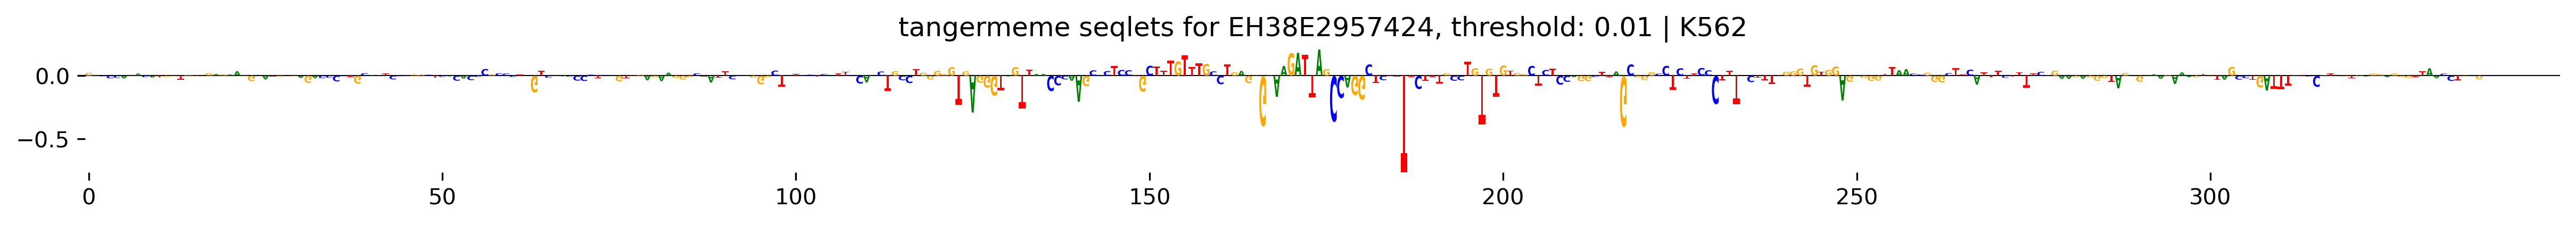

In [19]:
# EH38E2957424- MYBPC3 distal enhancer, ~6.8kb away
# K562
plot_specific_logos(annotated_seqlets,
                    'K562',
                    'EH38E2957424',
                    plotLogo_tensors,
                    True)

In [20]:
mean_groupy.loc['EH38E2957424',:]

k562_ref_pred      0.300818
k562_alt_pred      0.316469
k562_skew_pred     0.015651
hepg2_ref_pred     0.693191
hepg2_alt_pred     0.687002
hepg2_skew_pred   -0.006189
sknsh_ref_pred     0.491213
sknsh_alt_pred     0.495490
sknsh_skew_pred    0.004277
Name: EH38E2957424, dtype: float64

In [12]:
# load raw tensors
rawTensors = torch.load('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/chr2_raw_tensors.pt')

In [13]:
rawTensors['K562']['EH38E3390418'].shape#[:,147:153].shape

torch.Size([4, 350])

In [14]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Set rcParams to ensure fonts are editable in Illustrator
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

def plot_final_lollipop(numpy_data, title="Alternate Base Analysis"):
    """
    Plots a 2D NumPy array as a series of lollipop plots with several
    customizations for publication quality.

    - Ignores zero-value data points.
    - Removes gridlines.
    - Uses custom legend labels and title.

    Args:
        numpy_data (np.ndarray): A 2D NumPy array of shape (4, N).
        title (str): The title for the plot.
    """
    # --- 1. Input Validation and Data Preparation ---
    if not isinstance(numpy_data, np.ndarray) or numpy_data.ndim != 2 or numpy_data.shape[0] != 4:
        raise ValueError("Input must be a 2D NumPy array with shape (4, N)")

    data = numpy_data
    num_series, num_points = data.shape
    x_values = np.arange(num_points)
    
    # Custom colors and legend labels as requested
    colors = ['green', 'blue', 'gold', 'red']
    legend_labels = ['A', 'C', 'G', 'T']
    
    # --- 2. Create the Plot ---
    # Use a style that is clean and doesn't have a default grid
    plt.style.use('seaborn-v0_8-ticks') 
    fig, ax = plt.subplots(figsize=(20, 3), dpi=300)

    # --- 3. Plot each series, filtering out zeros ---
    for i in range(num_series):
        y_series = data[i]
        
        # Create a mask to select only non-zero values
        non_zero_mask = y_series != 0
        x_plot = x_values[non_zero_mask]
        y_plot = y_series[non_zero_mask]
        
        # Skip plotting if the entire series was zero
        if len(x_plot) == 0:
            continue
            
        # Create the stem plot with the filtered data
        markerline, stemlines, baseline = ax.stem(
            x_plot,
            y_plot,
            label=legend_labels[i],
            basefmt=' '
        )
        
        # Apply custom styling
        plt.setp(stemlines, color='gray', linewidth=0.8)
        plt.setp(markerline, marker='o', markersize=5,
                 markerfacecolor=colors[i],
                 markeredgecolor=colors[i])

    # --- 4. Final Customizations ---
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel("Genomic Position Index", fontsize=12)
    ax.set_ylabel("Value", fontsize=12)
    ax.set_xlim(-1, num_points)
    
    # Remove gridlines explicitly
    ax.grid(False)
    
    # Add the custom legend
    ax.legend(title='Alt Base', frameon=False, facecolor='white', framealpha=0.8, loc='upper right')
    
    # Remove top and right spines for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    # Save in both PDF and PNG formats
    plt.savefig('EH38E3390418_lollipop.pdf')
    #plt.savefig("final_lollipop_plot.png", dpi=300)

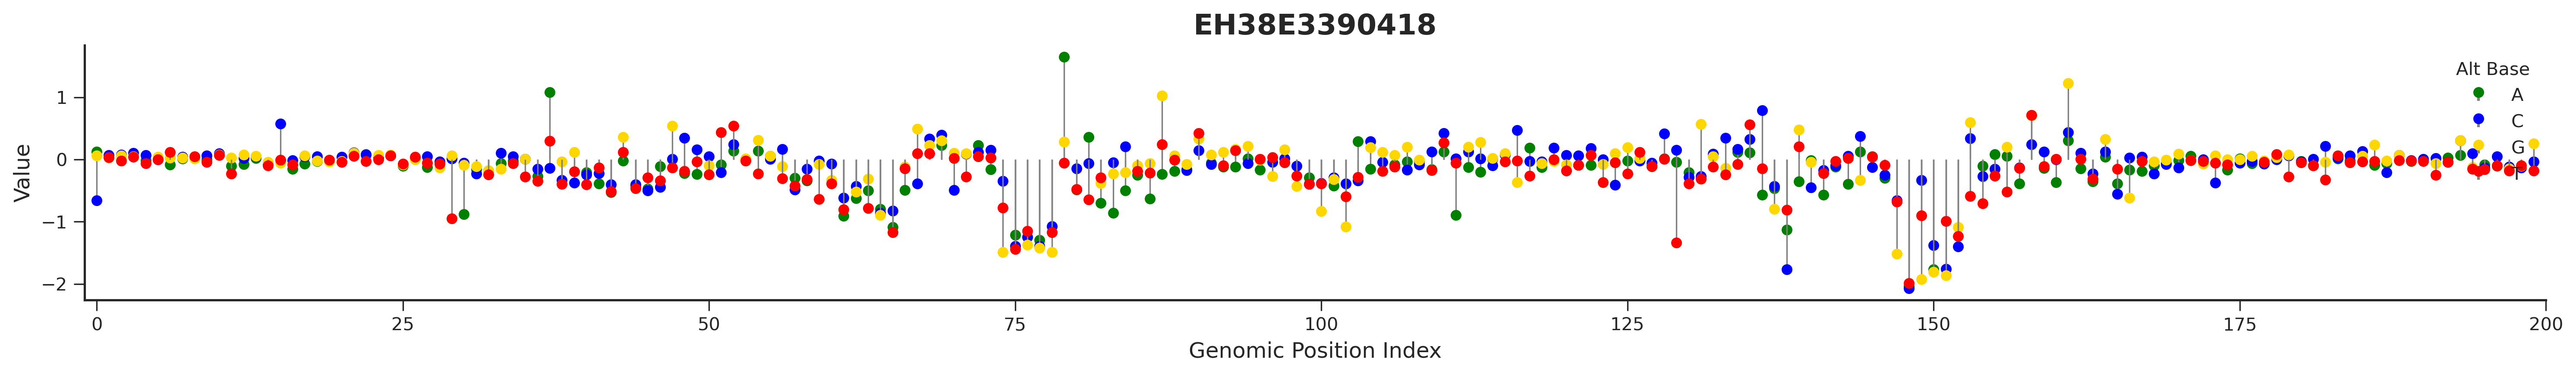

In [32]:
plot_final_lollipop(rawTensors['K562']['EH38E3390418'][:,73:-77].cpu().numpy(), 'EH38E3390418')

In [28]:
rawTensors['K562']['EH38E3390418'][:,73:-77].shape

torch.Size([4, 200])